In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

# Exercise 6.1


## Code implementation

### Gibbs sampling implementation

```C++
  if(_sim_type == 3)
  { 
    //Gibbs sampler for Ising
    double delta_E = 2.0 * ( 
      _J * (_particle(this->pbc(i-1)).getspin() 
          + _particle(this->pbc(i+1)).getspin() ) 
    + _H 
    );
    
    double p_up =1./(1+exp(-_beta*delta_E));

    //actual sampling
    if(_rnd.Rannyu()<p_up)
    {
      _particle(i).setspin(1);
    }
    else
    {
      _particle(i).setspin(-1);
    }
    _naccepted++;
        
  } 
```


### Main loop temperature update
Once assigned values to the temperature's variables `tmax`, `tmin` and `step_temp` the code structure is the usual NSL structure but with an additional loop on temperature:

```C++
int nstep_temp=int((tmax-tmin)/step_temp);

for(int ts=0; ts<nstep_temp; ts++)
{
  SYS.set_temp(tmin+ts*step_temp);

  SYS.initialize_properties();
  SYS.block_reset(0);
  int nb=SYS.get_nbl();
    
  for(int i=0; i < SYS.get_nbl(); i++)
  { //loop over blocks

    for(int j=0; j < SYS.get_nsteps(); j++)
    { //loop over steps in a block
      SYS.step();
      SYS.measure();
    }
    SYS.averages(i+1);
    SYS.block_reset(i+1);
  }
  SYS.write_finals_props();
  SYS.finalize();
}
```
### Measure of internal energy
Inside the `measure` function i implemented the measure of internal energy as
```C++
double s_i, s_j;
for (int i=0; i<_npart; i++){
  s_i = double(_particle(i).getspin());
  s_j = double(_particle(this->pbc(i+1)).getspin());
  tenergy_temp += - _J * s_i * s_j - 0.5 * _H * (s_i + s_j);
}
tenergy_temp /= double(_npart);
_measurement(_index_tenergy) = tenergy_temp;
```

### Measure of Magnetization and Susceptibility
Inside the `measure` function i implemented the measure of Magnetization and Susceptibility as
```C++
if(_measure_chi or _measure_magnet)
  {
    double spin_sum=0;

    for(int i=0; i<_npart; i++)
    {
      spin_sum+=double(_particle(i).getspin());
    }

    if(_measure_magnet) _measurement(_index_magnet)=spin_sum/_npart ; 
    if(_measure_chi) _measurement(_index_chi)=_beta*pow(spin_sum, 2)/_npart;
  }
```
### Measure of specific heat
Inside the `measure` function:
```C++
if (_measure_cv) 
  _measurement(_index_cv ) = pow(tenergy_temp,2);  
```

After in the `averages` function the measure of cv is finalized by 
```C++
if(_measure_cv)
{
  _block_av(_index_cv)-= pow(_block_av(_index_tenergy), 2)/ double(_nsteps) ;
  _block_av(_index_cv)*=_beta*_beta*_npart;
}
```

## Data visualization
### Exact solutions

In [2]:
points=30
T = np.linspace(0.2,3.0,num=points)
beta = 1/T
J = 1.0
Ns = 50
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th
e = -J*( th + ch*thN )/( 1 + thN )
heat=((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)
h=0.02 #external field
b = 1/T
l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)
X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN)

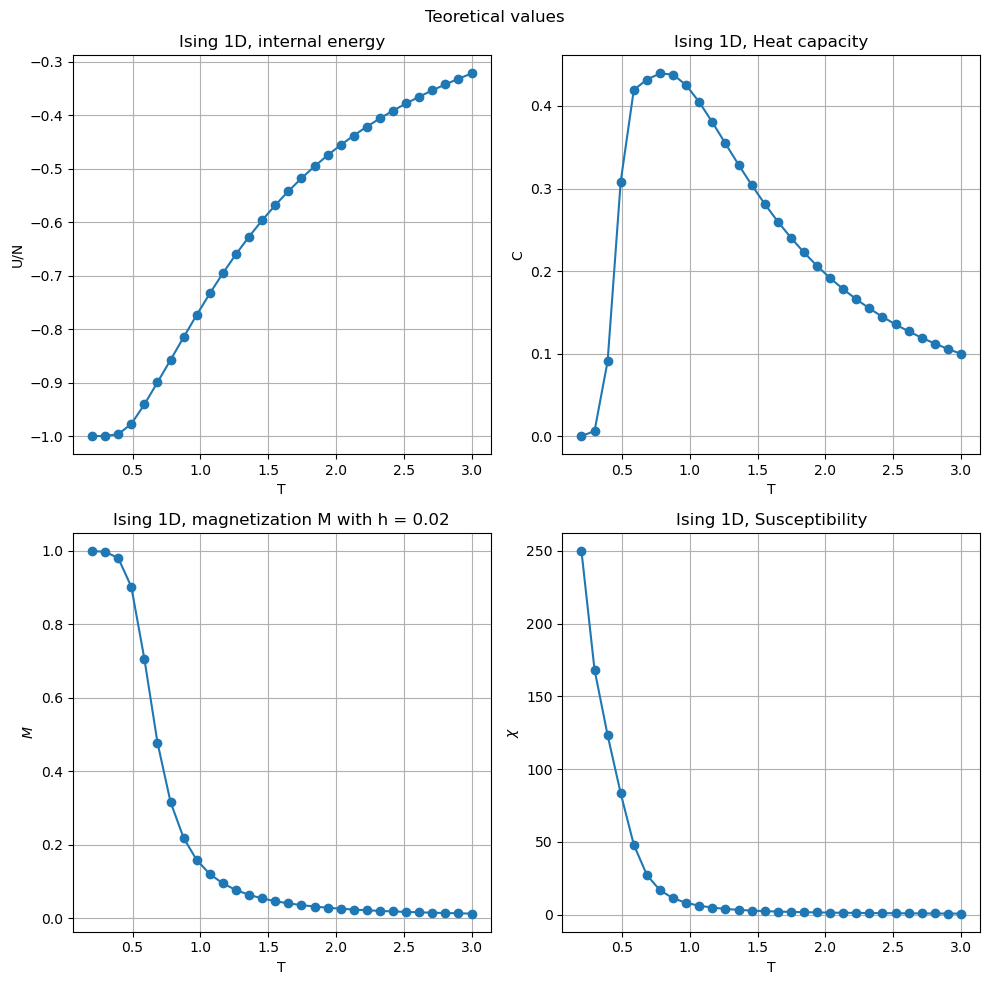

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle('Teoretical values')
ax[0,0].plot(T, e, label='teoretical', marker='o')
ax[0,0].set_title('Ising 1D, internal energy')
ax[0,0].set_xlabel('T')
ax[0,0].set_ylabel('U/N')



ax[0,1].plot(T, heat, label='teoretical', marker='o')
ax[0,1].set_title('Ising 1D, Heat capacity')
ax[0,1].set_xlabel('T')
ax[0,1].set_ylabel('C')



ax[1,0].plot(T, M, label='teoretical', marker='o')
ax[1,0].set_title('Ising 1D, magnetization M with h = 0.02')
ax[1,0].set_xlabel('T')
ax[1,0].set_ylabel(r'$M$')



ax[1,1].plot(T, X, label='teoretical', marker='o')
ax[1,1].set_title('Ising 1D, Susceptibility')
ax[1,1].set_xlabel('T')
ax[1,1].set_ylabel(r'$\chi$')


for k in range(2):
    for j in range(2):
        ax[k,j].grid()
plt.tight_layout()
plt.show()

## Simulated values

The values below are calculated using both Gibbs and Metropolis (labeled simply as MC) algorithms 

In [4]:
# Gibbs values
cvs_gb=pd.read_csv('OUTPUT/gibbs/specific_heat_T.dat', delimiter=r"\s+")
Ma_gb=pd.read_csv('OUTPUT/gibbs/magnetization_T.dat', delimiter=r"\s+")
TE_gb=pd.read_csv('OUTPUT/gibbs/total_energy_T.dat', delimiter=r"\s+")
Xs_gb=pd.read_csv('OUTPUT/gibbs/susceptibility_T.dat', delimiter=r"\s+")

In [5]:
# MC values
cvs_mc=pd.read_csv('OUTPUT/MRT2/specific_heat_T.dat', delimiter=r"\s+")
Ma_mc=pd.read_csv('OUTPUT/MRT2/magnetization_T.dat', delimiter=r"\s+")
TE_mc=pd.read_csv('OUTPUT/MRT2/total_energy_T.dat', delimiter=r"\s+")
Xs_mc=pd.read_csv('OUTPUT/MRT2/susceptibility_T.dat', delimiter=r"\s+")

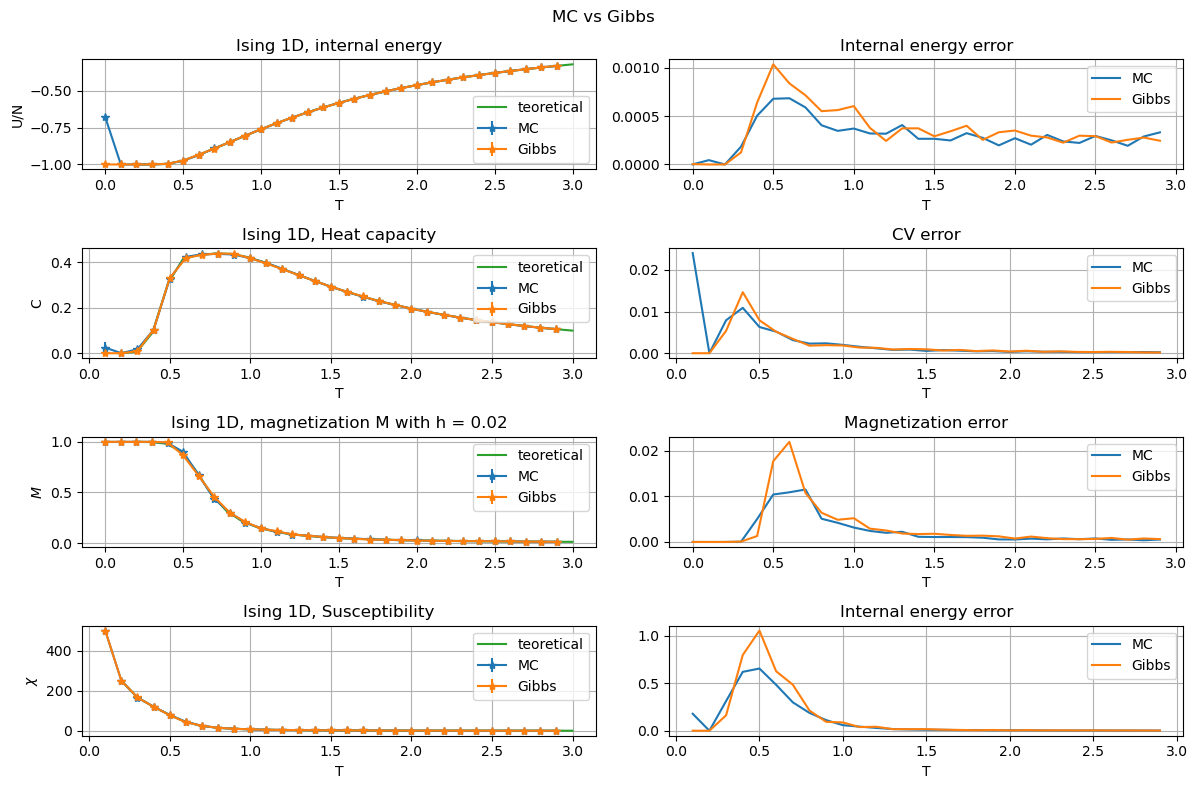

In [6]:
fig, ax = plt.subplots(4, 2, figsize=(12,8))
fig.suptitle('MC vs Gibbs')
ax[0,0].errorbar(TE_mc.TEMP, TE_mc.TE_AVE, yerr=TE_mc.ERROR, marker='*', label='MC')
ax[0,0].errorbar(TE_gb.TEMP, TE_gb.TE_AVE, yerr=TE_gb.ERROR, marker='*', label='Gibbs')
ax[0,0].plot(T, e, label='teoretical')

ax[0,0].set_title('Ising 1D, internal energy')
ax[0,0].set_xlabel('T')
ax[0,0].set_ylabel('U/N')

ax[0,1].set_title('Internal energy error')
ax[0,1].plot(TE_mc.TEMP, TE_mc.ERROR, label='MC')
ax[0,1].plot(TE_gb.TEMP, TE_gb.ERROR, label='Gibbs')
ax[0,1].set_xlabel('T')


ax[1,0].errorbar(cvs_mc.TEMP, cvs_mc.CV_AVE, yerr=cvs_mc.ERROR, marker='*', label='MC')
ax[1,0].errorbar(cvs_gb.TEMP, cvs_gb.CV_AVE, yerr=cvs_gb.ERROR, marker='*', label='Gibbs')
ax[1,0].plot(T, heat, label='teoretical')
ax[1,0].set_title('Ising 1D, Heat capacity')
ax[1,0].set_xlabel('T')
ax[1,0].set_ylabel('C')

ax[1,1].set_title('CV error')
ax[1,1].plot(cvs_mc.TEMP, cvs_mc.ERROR, label='MC')
ax[1,1].plot(cvs_gb.TEMP, cvs_gb.ERROR, label='Gibbs')
ax[1,1].set_xlabel('T')


ax[2,0].errorbar(Ma_mc.TEMP, Ma_mc.M_AVE, yerr=Ma_mc.ERROR, marker='*', label='MC')
ax[2,0].errorbar(Ma_gb.TEMP, Ma_gb.M_AVE, yerr=Ma_gb.ERROR, marker='*', label='Gibbs')
ax[2,0].plot(T, M, label='teoretical')
ax[2,0].set_title('Ising 1D, magnetization M with h = 0.02')
ax[2,0].set_xlabel('T')
ax[2,0].set_ylabel(r'$M$')

ax[2,1].set_title('Magnetization error')
ax[2,1].plot(Ma_mc.TEMP, Ma_mc.ERROR, label='MC')
ax[2,1].plot(Ma_gb.TEMP, Ma_gb.ERROR, label='Gibbs')
ax[2,1].set_xlabel('T')


ax[3,0].errorbar(Xs_mc.TEMP, Xs_mc.X_AVE, Xs_mc.ERROR, marker='*', label='MC')
ax[3,0].errorbar(Xs_gb.TEMP, Xs_gb.X_AVE, Xs_gb.ERROR, marker='*', label='Gibbs')
ax[3,0].plot(T, X, label='teoretical')
ax[3,0].set_title('Ising 1D, Susceptibility')
ax[3,0].set_xlabel('T')
ax[3,0].set_ylabel(r'$\chi$')

ax[3,1].set_title('Internal energy error')
ax[3,1].plot(Xs_mc.TEMP, Xs_mc.ERROR, label='MC')
ax[3,1].plot(Xs_gb.TEMP, Xs_gb.ERROR, label='Gibbs')
ax[3,1].set_xlabel('T')

for k in range(4):
    for j in [0,1]:
        ax[k,j].legend()
        ax[k,j].grid()
plt.tight_layout()
plt.show()

Below are reported the percentual distance respect the real values of both methods.

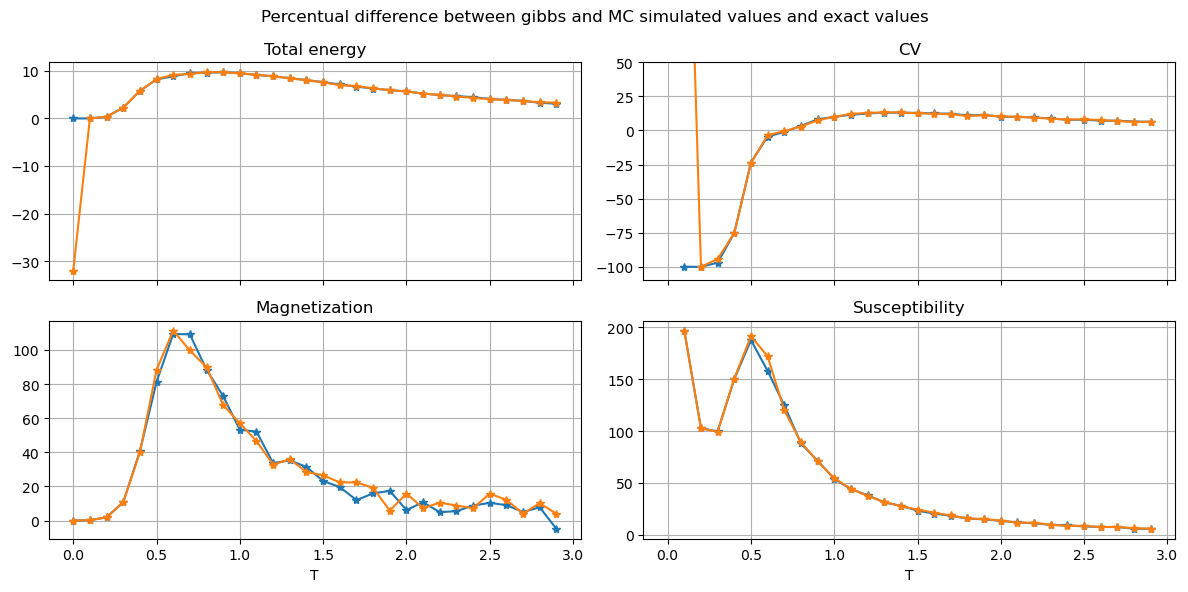

In [7]:

fig, ax = plt.subplots(2, 2, figsize=(12,6), sharex=True)#, sharey=True)
fig.suptitle('Percentual difference between gibbs and MC simulated values and exact values')

ax[0,0].set_title('Total energy')
ax[0,0].plot(TE_gb.TEMP, 100*(TE_gb.TE_AVE-e)/e, '-*',label='gibbs')
ax[0,0].plot(TE_mc.TEMP, 100*(TE_mc.TE_AVE-e)/e, '-*',label='MC')

ax[0,1].set_title('CV')
ax[0,1].plot(cvs_gb.TEMP, 100*(cvs_gb.CV_AVE-heat)/heat, '-*', label='gibbs')
ax[0,1].plot(cvs_mc.TEMP, 100*(cvs_mc.CV_AVE-heat)/heat, '-*', label='MC')
ax[0,1].set_ylim([-110, 50])

ax[1,0].set_title('Magnetization')
ax[1,0].plot(Ma_gb.TEMP, 100*(Ma_gb.M_AVE-M)/M, '-*',label='gibbs')
ax[1,0].plot(Ma_mc.TEMP, 100*(Ma_mc.M_AVE-M)/M, '-*',label='MC')

ax[1,1].set_title('Susceptibility')
ax[1,1].plot(Xs_gb.TEMP, 100*(Xs_gb.X_AVE-X)/X, '-*',label='gibbs')
ax[1,1].plot(Xs_mc.TEMP, 100*(Xs_mc.X_AVE-X)/X, '-*',label='MC')

for k in [0,1]:
    for j in [0,1]:
        ax[k,j].grid()
        ax[1,j].set_xlabel('T')
        
plt.tight_layout()
plt.show()